In [2]:
!pip install pandas numpy scikit-learn fairlearn matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from fairlearn.metrics import MetricFrame, demographic_parity_difference
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("heart_failure_readmission_dataset.csv")  # change path if needed

df.head()

,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
0,12911,76,Male,23.9,738,135.3,1.58,151,93,1,1,0,0.98,Medium,12.4,0
1,12521,77,Male,32.3,405,143.0,1.50,107,74,1,0,1,0.66,Medium,38.8,1
2,10155,42,Male,29.3,399,NaN,1.43,121,97,1,0,1,0.93,Low,43.5,1
3,12088,83,Female,29.1,524,135.1,0.91,114,66,0,1,1,0.54,Low,33.3,1
4,10792,48,Female,24.2,301,139.5,0.54,122,79,1,1,1,0.78,High,21.3,0


In [9]:
# Handle categorical columns
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
0,12911,76,1,23.9,738,135.3,1.58,151,93,1,1,0,0.98,2,12.4,0
1,12521,77,1,32.3,405,143.0,1.50,107,74,1,0,1,0.66,2,38.8,1
2,10155,42,1,29.3,399,NaN,1.43,121,97,1,0,1,0.93,1,43.5,1
3,12088,83,0,29.1,524,135.1,0.91,114,66,0,1,1,0.54,1,33.3,1
4,10792,48,0,24.2,301,139.5,0.54,122,79,1,1,1,0.78,0,21.3,0


In [10]:
target = "readmitted_30d"   # change if column name differs
sensitive_feature = "income_level"   # important for bias

X = df.drop(target, axis=1)
y = df[target]
A = df[sensitive_feature]

In [11]:
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, A, test_size=0.2, random_state=42
)

In [15]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Handle missing values
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# 2. Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Train model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [16]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score

mf = MetricFrame(
    metrics=accuracy_score,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

print("Accuracy by group:")
print(mf.by_group)

Accuracy by group:
income_level
0    0.683938
1    0.614634
2    0.707921
Name: accuracy_score, dtype: float64


In [17]:
from fairlearn.metrics import demographic_parity_difference

dpd_before = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

print("Bias (Before mitigation):", dpd_before)

Bias (Before mitigation): 0.07946417288007074


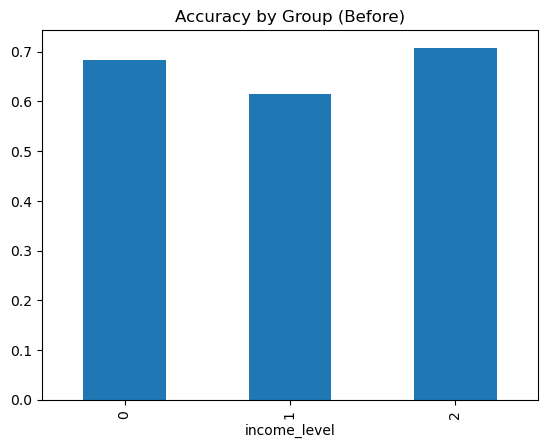

In [18]:
import matplotlib.pyplot as plt

mf.by_group.plot(kind="bar", title="Accuracy by Group (Before)")
plt.show()

In [20]:
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from sklearn.linear_model import LogisticRegression

mitigator = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=2000),
    constraints=DemographicParity()
)

mitigator.fit(X_train, y_train, sensitive_features=A_train)

y_pred_fair = mitigator.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

acc_before = accuracy_score(y_test, y_pred)
acc_after = accuracy_score(y_test, y_pred_fair)

print("Accuracy Before:", acc_before)
print("Accuracy After:", acc_after)

Accuracy Before: 0.6683333333333333
Accuracy After: 0.6783333333333333


In [22]:
from fairlearn.metrics import demographic_parity_difference

dpd_before = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

dpd_after = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred_fair,
    sensitive_features=A_test
)

print("Bias Before:", dpd_before)
print("Bias After:", dpd_after)

Bias Before: 0.07946417288007074
Bias After: 0.07916087451029946


In [23]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score

mf_before = MetricFrame(
    metrics=accuracy_score,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

mf_after = MetricFrame(
    metrics=accuracy_score,
    y_true=y_test,
    y_pred=y_pred_fair,
    sensitive_features=A_test
)

print("Before:\n", mf_before.by_group)
print("\nAfter:\n", mf_after.by_group)

Before:
 income_level
0    0.683938
1    0.614634
2    0.707921
Name: accuracy_score, dtype: float64

After:
 income_level
0    0.699482
1    0.619512
2    0.717822
Name: accuracy_score, dtype: float64


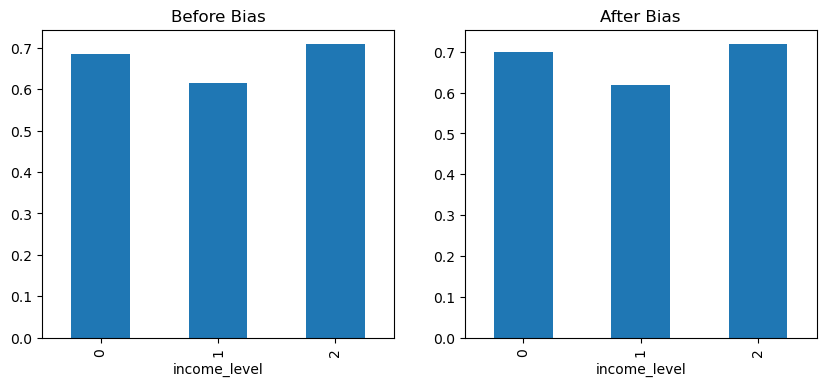

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10,4))

mf_before.by_group.plot(kind="bar", ax=ax[0], title="Before Bias")
mf_after.by_group.plot(kind="bar", ax=ax[1], title="After Bias")

plt.show()

In [25]:
print("========== FINAL RESULT ==========")
print("Accuracy Before:", acc_before)
print("Accuracy After :", acc_after)
print("Bias Before    :", dpd_before)
print("Bias After     :", dpd_after)

========== FINAL RESULT ==========
Accuracy Before: 0.6683333333333333
Accuracy After : 0.6783333333333333
Bias Before    : 0.07946417288007074
Bias After     : 0.07916087451029946


In [26]:
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from sklearn.linear_model import LogisticRegression

In [27]:
mitigator_eo = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=2000),
    constraints=EqualizedOdds()
)

mitigator_eo.fit(X_train, y_train, sensitive_features=A_train)

y_pred_fair_eo = mitigator_eo.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score

acc_before = accuracy_score(y_test, y_pred)
acc_after_eo = accuracy_score(y_test, y_pred_fair_eo)

print("Accuracy Before:", acc_before)
print("Accuracy After (EO):", acc_after_eo)

Accuracy Before: 0.6683333333333333
Accuracy After (EO): 0.6716666666666666


In [29]:
from fairlearn.metrics import equalized_odds_difference

eo_before = equalized_odds_difference(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

eo_after = equalized_odds_difference(
    y_true=y_test,
    y_pred=y_pred_fair_eo,
    sensitive_features=A_test
)

print("Equalized Odds Before:", eo_before)
print("Equalized Odds After :", eo_after)

Equalized Odds Before: 0.19664634146341464
Equalized Odds After : 0.24009146341463417


In [30]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score

mf_before = MetricFrame(
    metrics=accuracy_score,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

mf_after = MetricFrame(
    metrics=accuracy_score,
    y_true=y_test,
    y_pred=y_pred_fair_eo,
    sensitive_features=A_test
)

print("Before:\n", mf_before.by_group)
print("\nAfter (Equalized Odds):\n", mf_after.by_group)

Before:
 income_level
0    0.683938
1    0.614634
2    0.707921
Name: accuracy_score, dtype: float64

After (Equalized Odds):
 income_level
0    0.683938
1    0.609756
2    0.722772
Name: accuracy_score, dtype: float64


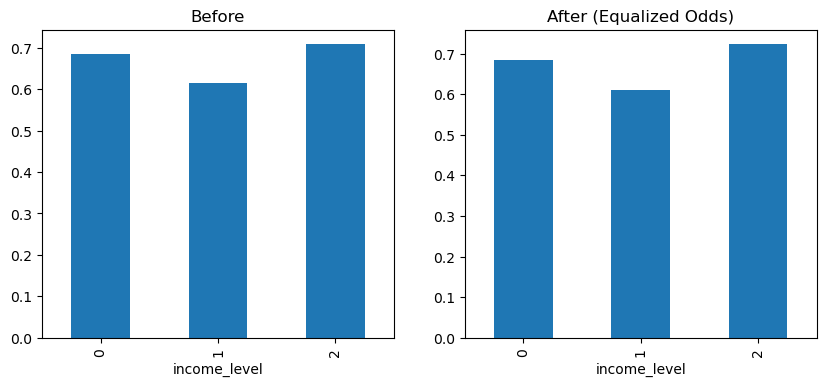

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10,4))

mf_before.by_group.plot(kind="bar", ax=ax[0], title="Before")
mf_after.by_group.plot(kind="bar", ax=ax[1], title="After (Equalized Odds)")

plt.show()